# Практика 4: Введение в GAN

`Генеративно-состязательная сеть (GAN)` состоит из двух нейросетей: генератора и дискриминатора. Генератор создаёт фейковые данные, дискриминатор пытается их отличить от реальных. Начнём с создания генератора: используем `torch.nn.Sequential`, добавляем `линейные слои`, `ReLU` и `Tanh` для вывода изображений в диапазоне [-1,1]. Далее создаём `дискриминатор`: он принимает изображение и предсказывает, реальное оно или нет, используя `LeakyReLU` и `Sigmoid` на выходе. Настроим функцию потерь (`BCELoss`) и оптимизатор (`Adam`). Обучаем модель: дискриминатор обновляется чаще генератора, чтобы не дать последнему слишком быстро научиться обманывать. Следим за тем, чтобы градиенты не исчезали, экспериментируем с различными функциями активации и архитектурой.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

from tqdm.auto import tqdm

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

device

c:\Users\semen\works\NN2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cuda')

In [3]:
image_size = 28 * 28
num_channels = 1

latent_dim = 100
hidden_dim_g = 256
hidden_dim_d = 256

batch_size = 128
num_epochs = 40
lr = 0.0002
beta1 = 0.5
beta2 = 0.9

d_steps = 1

fixed_noise = torch.randn(64, latent_dim, device=device)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader_generator = torch.Generator()
loader_generator.manual_seed(42)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    generator=loader_generator
)

print("Train samples:", len(train_dataset))

Train samples: 60000


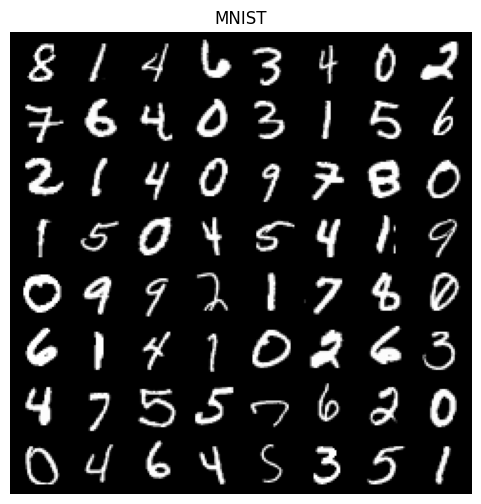

In [5]:
real_images, _ = next(iter(train_loader))

fig, ax = plt.subplots(figsize=(6, 6))
grid = make_grid(real_images[:64], nrow=8, normalize=True, value_range=(-1, 1))
ax.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
ax.axis("off")
ax.set_title("MNIST")
plt.show()

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, image_size, hidden_dim=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim, hidden_dim * 2),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim * 2, hidden_dim * 4),
            nn.ReLU(inplace=True),

            nn.Linear(hidden_dim * 4, image_size),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.model(z)
        return x.view(z.size(0), 1, 28, 28)

In [7]:
class Discriminator(nn.Module):
    def __init__(self, image_size, hidden_dim=256):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [8]:
G = Generator(latent_dim=latent_dim, image_size=image_size, hidden_dim=hidden_dim_g).to(device)
D = Discriminator(image_size=image_size, hidden_dim=hidden_dim_d).to(device)

In [9]:
@torch.no_grad()
def show_generated_images(generator, noise, title="Сгенерированные изображения"):
    generator.eval()
    fake_images = generator(noise).cpu()
    
    fig, ax = plt.subplots(figsize=(6, 6))
    grid = make_grid(fake_images, nrow=8, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(title)
    plt.show()
    
    generator.train()

In [10]:
def train_loop(D, G, num_epochs):
    g_losses = []
    d_losses = []

    loss_f = nn.BCELoss()
    optimizer_G = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
    optimizer_D = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

    progress_bar = tqdm(range(num_epochs), desc=f"Processing")
    for epoch in progress_bar:
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for batch_idx, (real_images, _) in enumerate(train_loader):
            real_images = real_images.to(device)
            batch_current = real_images.size(0)

            real_labels = torch.ones(batch_current, 1, device=device)
            fake_labels = torch.zeros(batch_current, 1, device=device)

            
            # 1. Обучение дискриминатора
            for _ in range(d_steps):
                optimizer_D.zero_grad()

                real_preds = D(real_images)
                d_loss_real = loss_f(real_preds, real_labels)

                z = torch.randn(batch_current, latent_dim, device=device)
                fake_images = G(z).detach()
                fake_preds = D(fake_images)
                d_loss_fake = loss_f(fake_preds, fake_labels)

                d_loss = d_loss_real + d_loss_fake
                d_loss.backward()
                optimizer_D.step()

            # 2. Обучение генератора
            optimizer_G.zero_grad()

            z = torch.randn(batch_current, latent_dim, device=device)
            fake_images = G(z)
            fake_preds = D(fake_images)

            g_loss = loss_f(fake_preds, real_labels)
            g_loss.backward()
            optimizer_G.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d_loss = epoch_d_loss / len(train_loader)
        avg_g_loss = epoch_g_loss / len(train_loader)

        d_losses.append(avg_d_loss)
        g_losses.append(avg_g_loss)

        progress_bar.set_postfix({
            "D Loss": f"{avg_d_loss:.4f}",
            "G Loss" : f"{avg_g_loss:.4f}"
        })

        if (epoch + 1) % 5 == 0 or epoch == 0:
            show_generated_images(G, fixed_noise, title=f"Эпоха {epoch + 1}")
    
    return g_losses, d_losses

Processing:   0%|          | 0/40 [00:59<?, ?it/s, D Loss=1.0490, G Loss=1.1773]

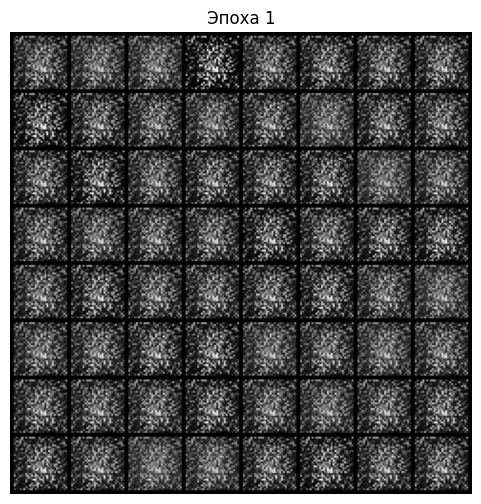

Processing:  10%|█         | 4/40 [02:19<15:01, 25.03s/it, D Loss=0.6976, G Loss=5.8531]

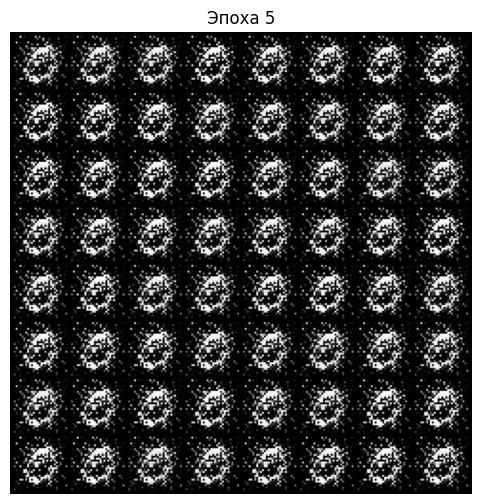

Processing:  22%|██▎       | 9/40 [03:37<08:38, 16.72s/it, D Loss=0.6969, G Loss=8.0952]

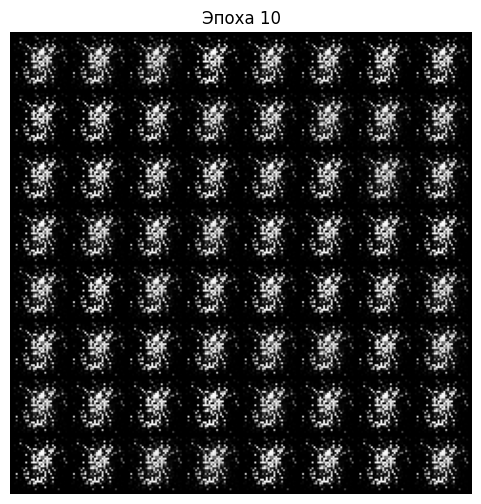

Processing:  35%|███▌      | 14/40 [04:54<06:48, 15.72s/it, D Loss=0.8092, G Loss=5.0543]

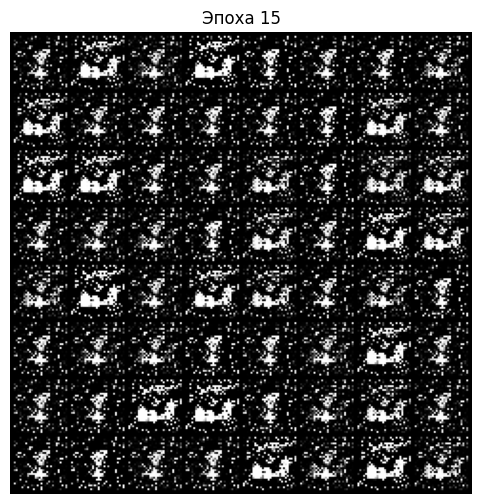

Processing:  48%|████▊     | 19/40 [06:11<05:26, 15.55s/it, D Loss=0.6538, G Loss=6.2055]

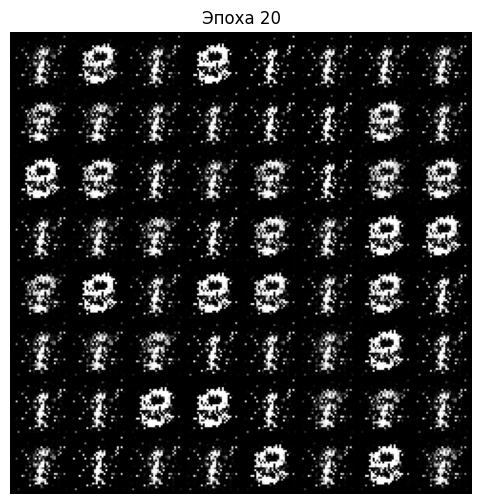

Processing:  60%|██████    | 24/40 [07:29<04:11, 15.75s/it, D Loss=0.6482, G Loss=5.2837]

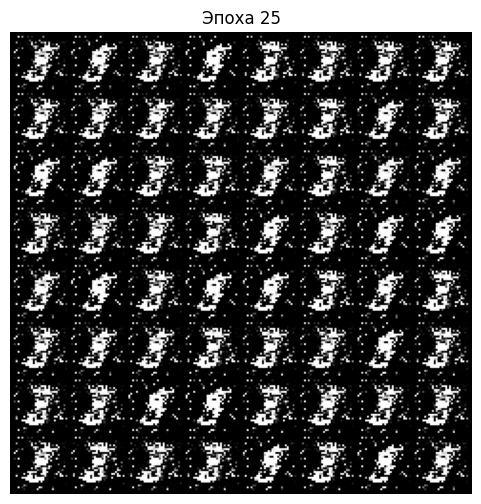

Processing:  72%|███████▎  | 29/40 [08:47<02:51, 15.57s/it, D Loss=0.4708, G Loss=5.3094]

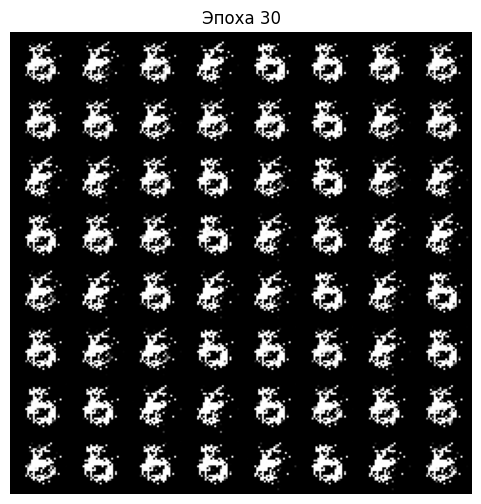

Processing:  85%|████████▌ | 34/40 [10:04<01:33, 15.51s/it, D Loss=0.3345, G Loss=7.6083]

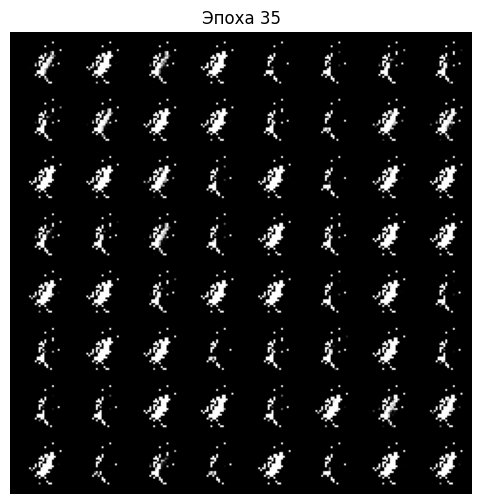

Processing:  98%|█████████▊| 39/40 [11:22<00:15, 15.61s/it, D Loss=0.2533, G Loss=8.9396] 

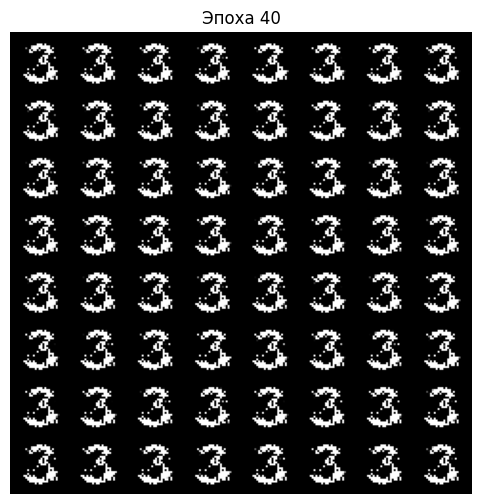

Processing: 100%|██████████| 40/40 [11:22<00:00, 17.07s/it, D Loss=0.2533, G Loss=8.9396]


In [11]:
g_losses, d_losses = train_loop(D= D, G= G, num_epochs= num_epochs)

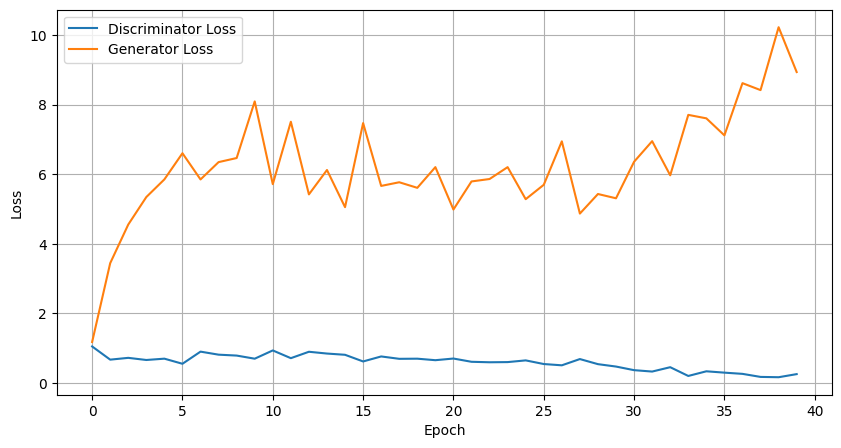

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

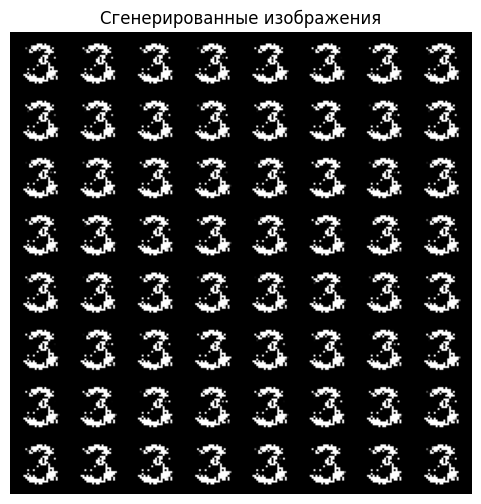

In [13]:
show_generated_images(G, fixed_noise)